# GrowthLens Classification Project

The goal is to classify companies as:

-   **Opportunity:** three-year market-cap growth above 50%.
-   **Not Opportunity:** three-year market-cap growth of 50% or less.

The notebook follows one clear workflow:

**Loading → Cleaning → Target Creation → EDA → Feature Engineering →
Splitting → Preprocessing → Modeling → Evaluation**

## 0. Setup and GPU Monitoring

In [ ]:
!pip install -q nvidia-ml-py catboost

import time
import threading
import numpy as np
import pandas as pd
import cudf
import cupy as cp
import pynvml
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

pynvml.nvmlInit()
gpu = pynvml.nvmlDeviceGetHandleByIndex(0)

gpu_usage = []
gpu_memory = []
monitoring = False
performance_results = []

def record_gpu():
    while monitoring:
        usage = pynvml.nvmlDeviceGetUtilizationRates(gpu).gpu
        memory = pynvml.nvmlDeviceGetMemoryInfo(gpu).used / 1024**2
        gpu_usage.append(usage)
        gpu_memory.append(memory)
        time.sleep(0.2)

TARGET = "target_marketcap_growth_3y_pct"
LIMIT = 50

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00


The monitoring function records GPU utilization and memory every 0.2
seconds while a model is running.

## 1. Data Loading

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = (
    "/content/drive/MyDrive/GROWTHLENS/"
    "growthlens_structured_1m.parquet"
)

start = time.perf_counter()

df = cudf.read_parquet(DATA_PATH)
df["observation_date"] = cudf.to_datetime(df["observation_date"])

loading_time = time.perf_counter() - start

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Companies:", df["ticker"].nunique())
print("Dates:", df["observation_date"].min(), "to", df["observation_date"].max())
print("Loading time:", round(loading_time, 2), "seconds")

display(df.head())

Mounted at /content/drive
Rows: 1000000
Columns: 48
Companies: 2454
Dates: 2021-04-30T00:00:00 to 2023-07-27T00:00:00
Loading time: 9.96 seconds


,cik,ticker,company_name,exchange,sector,industry,observation_date,size_bucket,public_age_years,raw_close,...,net_margin_pct,operating_margin_pct,fcf_margin_pct,return_on_assets_pct,return_on_equity_pct,liabilities_to_assets,target_marketcap_growth_3y_pct,target_total_return_3y_pct,target_sector_top_quartile_3y,temporal_split
0,19745,CPK,CHESAPEAKE UTILITIES CORP,NYSE,Utilities,Oil & Gas Production,2022-05-03,mid,<NA>,123.015,...,14.643980,23.003397,-6.389832412,3.946627,10.781910,<NA>,40.219779,14.839798,1,train
1,50725,GFF,GRIFFON CORP,NYSE,Industrials,Building Products,2022-05-03,small,<NA>,22.950,...,3.488509,7.512598,<NA>,3.041097,9.813568,0.690113008,157.988525,266.980638,1,train
2,69891,FIZZ,NATIONAL BEVERAGE CORP,Nasdaq,Consumer Staples,Beverages (Production/Distribution),2022-05-03,mid,<NA>,43.540,...,16.241781,21.248170,15.71166096,31.251694,48.917828,0.361138977,-0.662438,6.114458,0,train
3,1776909,CURI,CuriosityStream Inc.,Nasdaq,Consumer Discretionary,Movies/Entertainment,2022-05-03,micro,2,2.155,...,-52.812899,-73.643367,-103.2724772,-17.297245,-23.240806,0.255738172,72.825575,69.059829,1,train
4,1812727,EZRA,"Reliance Global Group, Inc.",Nasdaq,Finance,Specialty Insurers,2022-05-03,micro,<NA>,2.650,...,-217.278468,-29.991965,-23.93720957,-76.234998,80.942072,1.941846386,-89.396802,-99.835730,0,train


## 2. Data Cleaning

Infinite values are replaced once in this phase. Rows are not deleted
because several financial features contain missing values.

In [ ]:
numeric_columns = df.select_dtypes(include=["number"]).columns

df[numeric_columns] = df[numeric_columns].replace([np.inf, -np.inf],np.nan)

df = df.dropna(subset=[TARGET])
missing_values = (df.isnull().sum().sort_values(ascending=False).head(10))

display(missing_values)

research_development_usd    584530
fcf_margin_pct              446328
public_age_years            445208
operating_margin_pct        369146
revenue_growth_yoy_pct      321623
free_cash_flow_usd          272540
net_margin_pct              263600
capex_usd                   262106
revenue_usd                 249625
operating_income_usd        239758
dtype: int64

Missing numerical values will be replaced later using medians calculated
from the training set only. Missing categorical values will be replaced
with `Unknown`.

## 3. Target Creation

A company is an opportunity when its three-year market-cap growth is
greater than 50%.

In [ ]:
df["opportunity"] = (df[TARGET] > LIMIT).astype("int32")

print("Not Opportunity:", (df["opportunity"] == 0).sum())
print("Opportunity:", (df["opportunity"] == 1).sum())
print("Opportunity (%):", round(float(df["opportunity"].mean() * 100), 2))

Not Opportunity: 727762
Opportunity: 272238
Opportunity (%): 27.22


## 4. Exploratory Data Analysis

### 4.1 Target Class Distribution

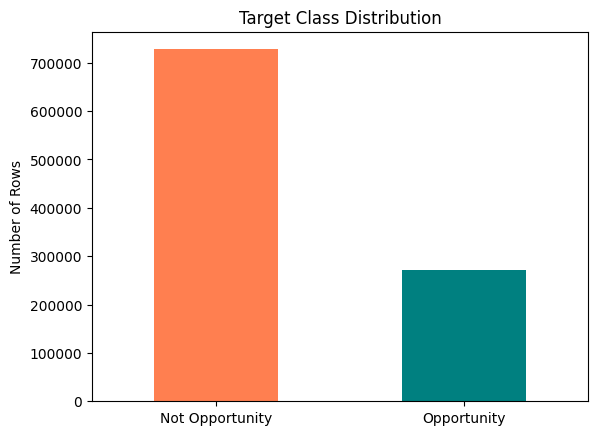

In [ ]:
target_counts = (df["opportunity"].value_counts().sort_index().to_pandas())

target_counts.index = ["Not Opportunity", "Opportunity"]
target_counts.plot(kind="bar", color=["coral", "teal"])

plt.title("Target Class Distribution")
plt.ylabel("Number of Rows")
plt.xticks(rotation=0)
plt.show()

### 4.2 Three-Year Growth Distribution

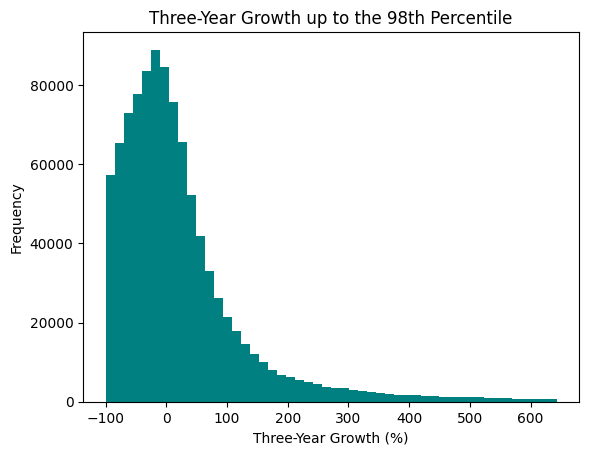

count    1000000.000000
mean          47.983311
std          234.856029
min          -99.896437
25%          -44.800718
50%           -1.371906
75%           57.598895
max         4999.467480
Name: target_marketcap_growth_3y_pct, dtype: float64

In [ ]:
upper_limit = df[TARGET].quantile(0.98)
target_plot = df[df[TARGET] <= upper_limit][TARGET].to_pandas()

plt.hist(target_plot, bins=50, color="teal")
plt.title("Three-Year Growth up to the 98th Percentile")
plt.xlabel("Three-Year Growth (%)")
plt.ylabel("Frequency")
plt.show()

display(df[TARGET].describe())

### 4.3 Opportunity Rate Over Time

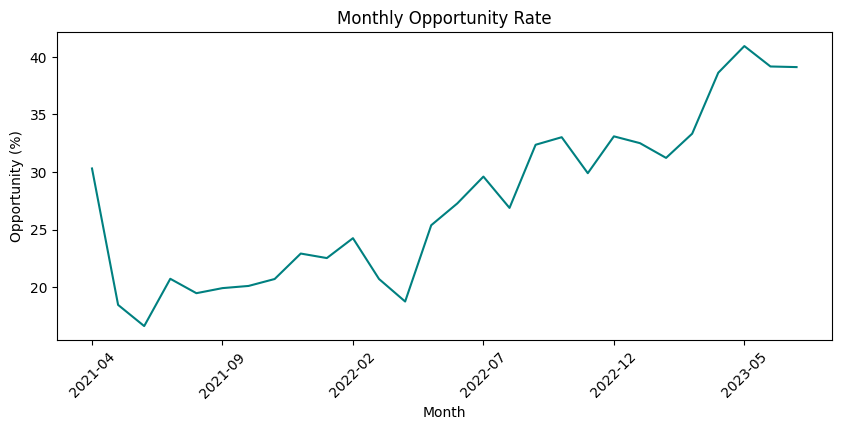

In [ ]:
df["month"] = df["observation_date"].dt.strftime("%Y-%m")

monthly_opportunity = (
    df.groupby("month")["opportunity"]
    .mean()
    .sort_index()
    .to_pandas() * 100
)

monthly_opportunity.plot(figsize=(10, 4), color="teal")
plt.title("Monthly Opportunity Rate")
plt.xlabel("Month")
plt.ylabel("Opportunity (%)")
plt.xticks(rotation=45)
plt.show()

### 4.4 Company Observations

Companies: 2454
Minimum rows: 1
Average rows: 407.5
Maximum rows: 542


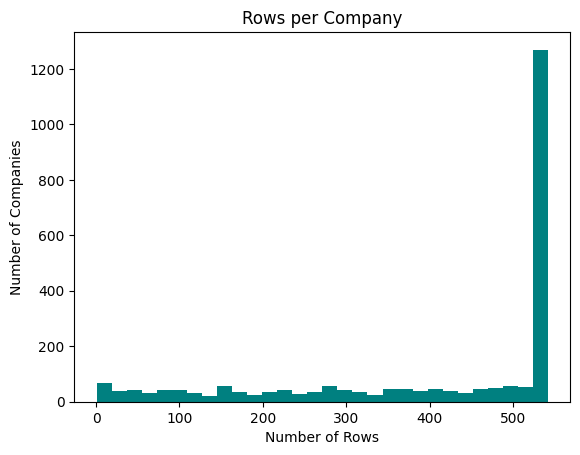

In [ ]:
rows_per_company = df["ticker"].value_counts().to_pandas()

print("Companies:", len(rows_per_company))
print("Minimum rows:", rows_per_company.min())
print("Average rows:", round(rows_per_company.mean(), 2))
print("Maximum rows:", rows_per_company.max())

plt.hist(rows_per_company, bins=30, color="teal")
plt.title("Rows per Company")
plt.xlabel("Number of Rows")
plt.ylabel("Number of Companies")
plt.show()

### 4.5 Missing Values

In [ ]:
missing_percentage = (
    df.isnull().sum()
    / len(df) * 100
)

missing_percentage = (
    missing_percentage
    .sort_values(ascending=False)
    .head(10)
)

display(missing_percentage)

research_development_usd    58.4530
fcf_margin_pct              44.6328
public_age_years            44.5208
operating_margin_pct        36.9146
revenue_growth_yoy_pct      32.1623
free_cash_flow_usd          27.2540
net_margin_pct              26.3600
capex_usd                   26.2106
revenue_usd                 24.9625
operating_income_usd        23.9758
dtype: float64

### 4.6 Numerical Correlations

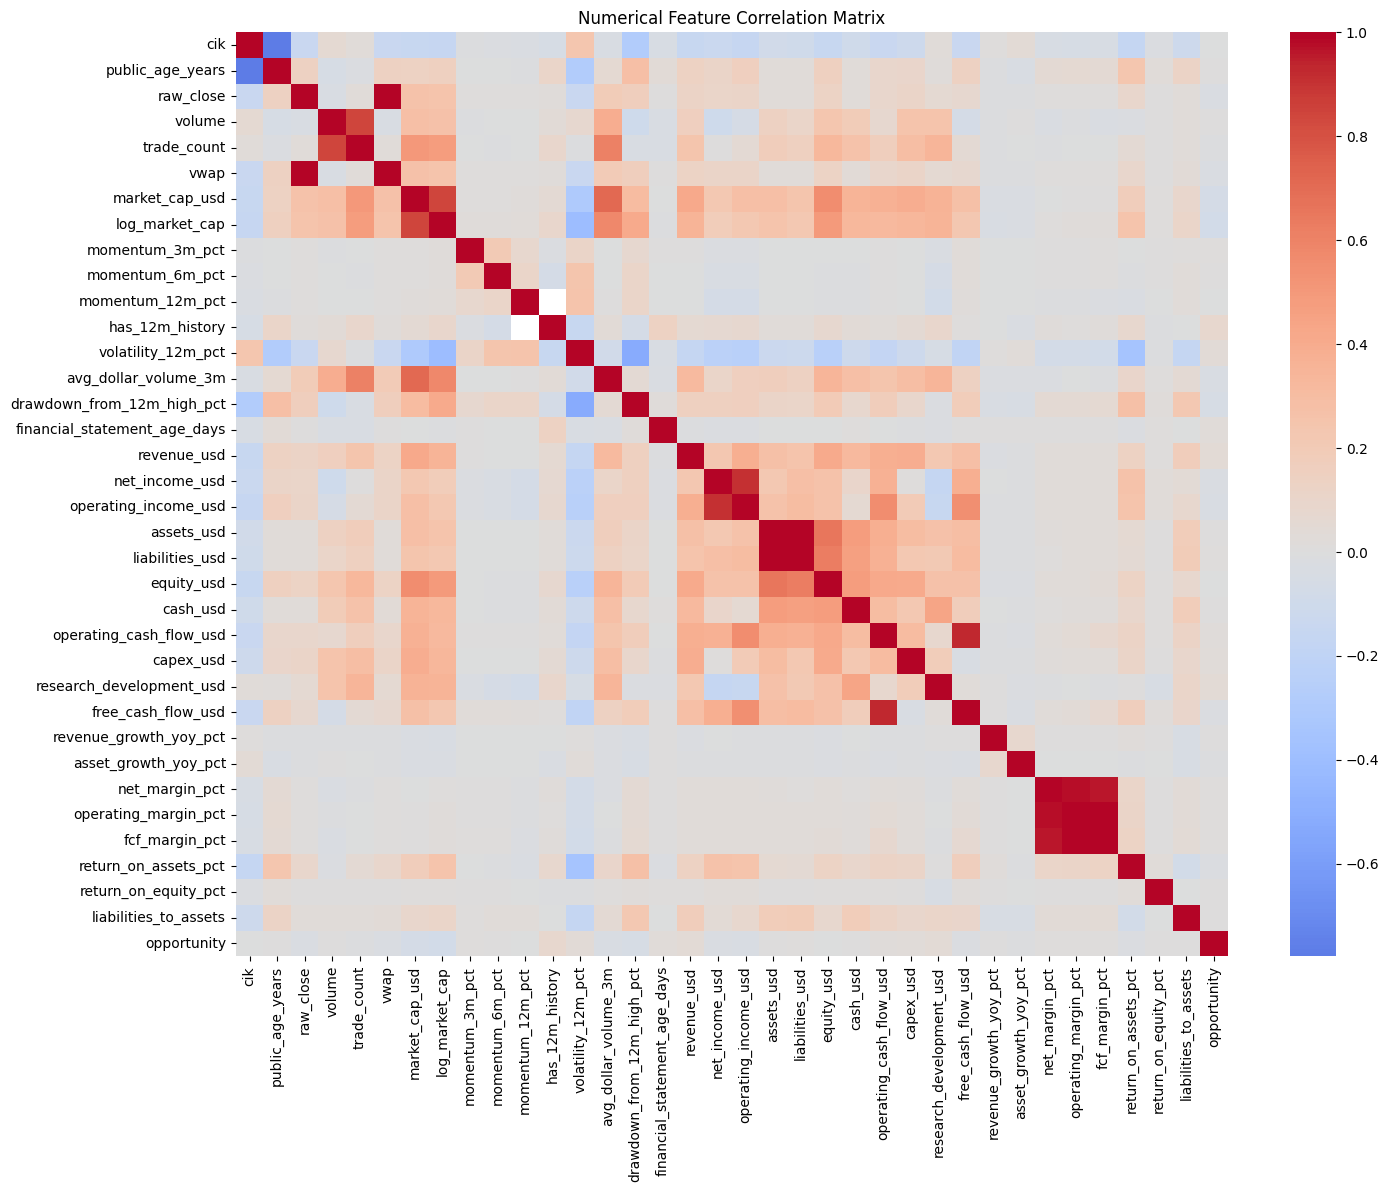

In [ ]:
correlation_data = df.select_dtypes(include=["number"])

correlation_data = correlation_data.drop(
    columns=[TARGET,"target_total_return_3y_pct","target_sector_top_quartile_3y"]
)

correlation_data = correlation_data.sample(
    n=100000,
    random_state=42
).to_pandas()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_data.corr(), cmap="coolwarm", center=0)
plt.title("Numerical Feature Correlation Matrix")
plt.show()

### 4.7 Opportunity Rate by Sector

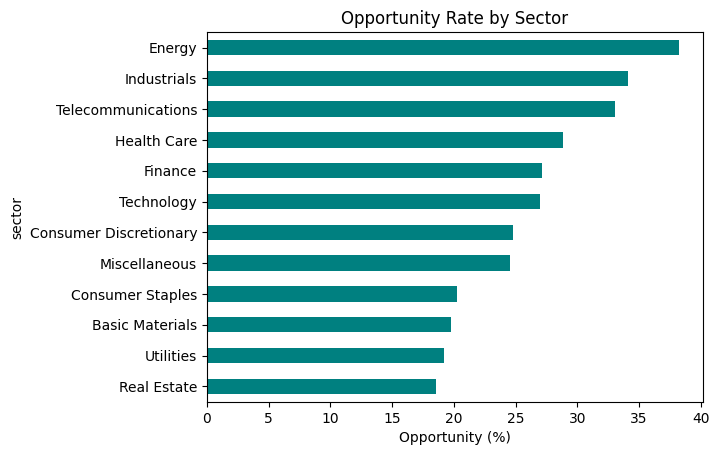

In [ ]:
sector_opportunity = (
    df.groupby("sector")["opportunity"]
    .mean()
    .sort_values()
    .to_pandas() * 100
)

sector_opportunity.plot(kind="barh", color="teal")
plt.title("Opportunity Rate by Sector")
plt.xlabel("Opportunity (%)")
plt.show()

The target is imbalanced and changes across time. Most numerical
features have weak individual linear relationships with the target, so
tree-based models may be useful for learning nonlinear interactions.

## 5. Feature Engineering and Selection

In [ ]:
market_cap = df["market_cap_usd"].replace(0, np.nan)

df["revenue_to_marketcap"] = df["revenue_usd"] / market_cap
df["earnings_yield"] = df["net_income_usd"] / market_cap
df["fcf_yield"] = df["free_cash_flow_usd"] / market_cap
df["cash_to_assets"] = df["cash_usd"] / (df["assets_usd"] + 1)

df["rd_intensity"] = (
    df["research_development_usd"]
    / (df["revenue_usd"].abs() + 1)
)

In [ ]:
categorical_features = [
    "exchange",
    "sector",
    "industry"
]

numeric_features = [
    "public_age_years",
    "log_market_cap",
    "momentum_3m_pct",
    "momentum_6m_pct",
    "momentum_12m_pct",
    "has_12m_history",
    "volatility_12m_pct",
    "avg_dollar_volume_3m",
    "drawdown_from_12m_high_pct",
    "financial_statement_age_days",
    "revenue_growth_yoy_pct",
    "asset_growth_yoy_pct",
    "net_margin_pct",
    "operating_margin_pct",
    "fcf_margin_pct",
    "return_on_assets_pct",
    "return_on_equity_pct",
    "liabilities_to_assets",
    "revenue_to_marketcap",
    "earnings_yield",
    "fcf_yield",
    "cash_to_assets",
    "rd_intensity"
]

FEATURES = categorical_features + numeric_features

print("Selected features:", len(FEATURES))

Selected features: 26


Identifiers, dates, split labels, and future target columns are excluded
from the model features to prevent leakage.

## 6. Data Splitting

### 6.1 Chronological 80/10/10 Split

This split is used by the cuML stacking model and CatBoost. Complete
dates remain in only one set.

In [ ]:
df = df.sort_values("observation_date").reset_index(drop=True)

dates = (
    df["observation_date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

train_cut = dates.iloc[int(len(dates) * 0.80)]
validation_cut = dates.iloc[int(len(dates) * 0.90)]

time_train = df[df["observation_date"] < train_cut]

time_validation = df[
    (df["observation_date"] >= train_cut) &
    (df["observation_date"] < validation_cut)
]

time_test = df[df["observation_date"] >= validation_cut]

print("Train:", len(time_train))
print("Validation:", len(time_validation))
print("Test:", len(time_test))
print("Train opportunity (%):", round(float(time_train["opportunity"].mean() * 100), 2))
print("Validation opportunity (%):", round(float(time_validation["opportunity"].mean() * 100), 2))
print("Test opportunity (%):", round(float(time_test["opportunity"].mean() * 100), 2))

Train: 793277
Validation: 101028
Test: 105695
Train opportunity (%): 24.54
Validation opportunity (%): 35.33
Test opportunity (%): 39.61


### 6.2 Three-Month / One-Month Experimental Split

XGBoost trains on three consecutive months and tests on the following
month. The windows do not reuse test months, but the three-year target
periods can still overlap, so this result is exploratory.

In [ ]:
df["year_month"] = df["observation_date"].dt.strftime("%Y-%m")

months = (
    df["year_month"]
    .drop_duplicates()
    .sort_values()
    .to_pandas()
    .tolist()
)

monthly_folds = []

for start in range(0, len(months) - 3, 4):
    train_months = months[start:start + 3]
    test_month = months[start + 3]
    monthly_folds.append([train_months, test_month])
    print("Train:", train_months, "| Test:", test_month)

print("Number of folds:", len(monthly_folds))

Train: ['2021-04', '2021-05', '2021-06'] | Test: 2021-07
Train: ['2021-08', '2021-09', '2021-10'] | Test: 2021-11
Train: ['2021-12', '2022-01', '2022-02'] | Test: 2022-03
Train: ['2022-04', '2022-05', '2022-06'] | Test: 2022-07
Train: ['2022-08', '2022-09', '2022-10'] | Test: 2022-11
Train: ['2022-12', '2023-01', '2023-02'] | Test: 2023-03
Train: ['2023-04', '2023-05', '2023-06'] | Test: 2023-07
Number of folds: 7


In [ ]:
monthly_split_results = []

for fold, (train_months, test_month) in enumerate(monthly_folds, start=1):

    fold_train = df[df["year_month"].isin(train_months)]
    fold_test = df[df["year_month"] == test_month]

    monthly_split_results.append({
        "Fold": fold,
        "Training Months": ", ".join(train_months),
        "Train Rows": len(fold_train),
        "Train Not Opportunity (%)":
            float((fold_train["opportunity"] == 0).mean() * 100),
        "Train Opportunity (%)":
            float((fold_train["opportunity"] == 1).mean() * 100),
        "Test Month": test_month,
        "Test Rows": len(fold_test),
        "Test Not Opportunity (%)":
            float((fold_test["opportunity"] == 0).mean() * 100),
        "Test Opportunity (%)":
            float((fold_test["opportunity"] == 1).mean() * 100)
    })

monthly_split_table = pd.DataFrame(monthly_split_results)

display(monthly_split_table.round(2))

,Fold,Training Months,Train Rows,Train Not Opportunity (%),Train Opportunity (%),Test Month,Test Rows,Test Not Opportunity (%),Test Opportunity (%)
0,1,"2021-04, 2021-05, 2021-06",72742,82.51,17.49,2021-07,36766,79.28,20.72
1,2,"2021-08, 2021-09, 2021-10",111885,80.18,19.82,2021-11,37292,79.30,20.70
2,3,"2021-12, 2022-01, 2022-02",111877,76.80,23.20,2022-03,42370,79.30,20.70
3,4,"2022-04, 2022-05, 2022-06",117359,76.10,23.90,2022-07,38720,70.40,29.60
4,5,"2022-08, 2022-09, 2022-10",125312,69.39,30.61,2022-11,17880,70.11,29.89
5,6,"2022-12, 2023-01, 2023-02",113085,67.70,32.30,2023-03,24712,66.68,33.32
6,7,"2023-04, 2023-05, 2023-06",115320,60.35,39.65,2023-07,34680,60.89,39.11


In [ ]:
gpu_usage.clear()
gpu_memory.clear()

monitoring = True
preprocessing_thread = threading.Thread(target=record_gpu)
preprocessing_thread.start()

preprocessing_start = time.perf_counter()

## 7. Preprocessing

All missing-value treatment, encoding, and scaling for the chronological
models is performed here once. Statistics are learned from the training
set only.

### 7.1 Missing Values

In [ ]:
X_base_train = time_train[FEATURES].copy()
X_base_validation = time_validation[FEATURES].copy()
X_base_test = time_test[FEATURES].copy()

for column in categorical_features:
    X_base_train[column] = X_base_train[column].fillna("Unknown")
    X_base_validation[column] = X_base_validation[column].fillna("Unknown")
    X_base_test[column] = X_base_test[column].fillna("Unknown")

for column in numeric_features:
    median = X_base_train[column].median()
    X_base_train[column] = X_base_train[column].fillna(median)
    X_base_validation[column] = X_base_validation[column].fillna(median)
    X_base_test[column] = X_base_test[column].fillna(median)

print("Missing values handled.")

Missing values handled.


### 7.2 CatBoost Data

CatBoost uses the original categorical columns, so its data is not
one-hot encoded or scaled.

In [ ]:
X_cat_train = X_base_train.to_pandas()
X_cat_validation = X_base_validation.to_pandas()
X_cat_test = X_base_test.to_pandas()

y_cpu_train = time_train["opportunity"].to_pandas().astype("int32")
y_cpu_validation = time_validation["opportunity"].to_pandas().astype("int32")
y_cpu_test = time_test["opportunity"].to_pandas().astype("int32")

print("Train:", X_cat_train.shape)
print("Validation:", X_cat_validation.shape)
print("Test:", X_cat_test.shape)

Train: (793277, 26)
Validation: (101028, 26)
Test: (105695, 26)


### 7.3 GPU Encoding and MinMax Scaling

This representation is used by the cuML stacking model. MinMaxScaler
maps each feature into a consistent numerical range.

In [ ]:
from cuml import set_global_output_type
from cuml.preprocessing import MinMaxScaler

set_global_output_type("cupy")

X_encoded_train = cudf.get_dummies(
    X_base_train,
    columns=categorical_features,
    dtype="float32"
)

X_encoded_validation = cudf.get_dummies(
    X_base_validation,
    columns=categorical_features,
    dtype="float32"
)

X_encoded_test = cudf.get_dummies(
    X_base_test,
    columns=categorical_features,
    dtype="float32"
)

X_encoded_validation = X_encoded_validation.reindex(
    columns=X_encoded_train.columns,
    fill_value=0
)

X_encoded_test = X_encoded_test.reindex(
    columns=X_encoded_train.columns,
    fill_value=0
)

X_encoded_train = X_encoded_train.astype("float32")
X_encoded_validation = X_encoded_validation.astype("float32")
X_encoded_test = X_encoded_test.astype("float32")

scaler = MinMaxScaler()

X_gpu_train = scaler.fit_transform(X_encoded_train.to_cupy())
X_gpu_validation = scaler.transform(X_encoded_validation.to_cupy())
X_gpu_test = scaler.transform(X_encoded_test.to_cupy())

y_gpu_train = time_train["opportunity"].to_cupy().astype(cp.int32)
y_gpu_validation = time_validation["opportunity"].to_cupy().astype(cp.int32)
y_gpu_test = time_test["opportunity"].to_cupy().astype(cp.int32)

print("Train:", X_gpu_train.shape)
print("Validation:", X_gpu_validation.shape)
print("Test:", X_gpu_test.shape)

Train: (793277, 180)
Validation: (101028, 180)
Test: (105695, 180)


In [ ]:
cp.cuda.Stream.null.synchronize()

preprocessing_time = time.perf_counter() - preprocessing_start

monitoring = False
preprocessing_thread.join()

preprocessing_avg_gpu = np.mean(gpu_usage)
preprocessing_peak_memory = max(gpu_memory)

preprocessing_results = pd.DataFrame({
    "Phase": ["Preprocessing"],
    "Execution Time (s)": [preprocessing_time],
    "Average GPU (%)": [preprocessing_avg_gpu],
    "Peak GPU Memory (MB)": [preprocessing_peak_memory]
})

display(preprocessing_results.round(2))

,Phase,Execution Time (s),Average GPU (%),Peak GPU Memory (MB)
0,Preprocessing,11.49,8.09,4296.19


## 8. Model Building and Evaluation

All models are evaluated with Accuracy, Balanced Accuracy, Precision,
Recall, F1, and AUC. GPU utilization, GPU memory, training time, and
inference time are also recorded.

## Model A: cuML Stacking — Chronological 80/10/10

Three cuML GPU classifiers are combined: Logistic Regression, Random
Forest, and Gaussian Naive Bayes. Their validation probabilities train
the final cuML Logistic Regression stacking layer.

In [ ]:
from cuml.linear_model import LogisticRegression
from cuml.ensemble import RandomForestClassifier
from cuml.naive_bayes import GaussianNB

pca_logistic = LogisticRegression(max_iter=1000,class_weight="balanced")

pca_forest = RandomForestClassifier(n_estimators=200,max_depth=12,random_state=42)

pca_bayes = GaussianNB()

pca_stack_model = LogisticRegression(max_iter=1000,class_weight="balanced")

In [ ]:
gpu_usage.clear()
gpu_memory.clear()

monitoring = True
gpu_thread = threading.Thread(target=record_gpu)
gpu_thread.start()

start = time.perf_counter()

pca_logistic.fit(X_pca_train, y_gpu_train)
pca_forest.fit(X_pca_train, y_gpu_train)
pca_bayes.fit(X_pca_train, y_gpu_train)

logistic_validation = pca_logistic.predict_proba(X_pca_validation)[:, 1]
forest_validation = pca_forest.predict_proba(X_pca_validation)[:, 1]
bayes_validation = pca_bayes.predict_proba(X_pca_validation)[:, 1]

stack_validation = cp.column_stack([logistic_validation,forest_validation,bayes_validation])

pca_stack_model.fit(stack_validation, y_gpu_validation)

cp.cuda.Stream.null.synchronize()
pca_stack_train_time = time.perf_counter() - start

monitoring = False
gpu_thread.join()

pca_stack_avg_gpu = np.mean(gpu_usage)
pca_stack_peak_memory = max(gpu_memory)

print("PCA components:", pca_components)
print("Training time:", round(pca_stack_train_time, 2), "seconds")
print("Average GPU:", round(pca_stack_avg_gpu, 2), "%")
print("Peak GPU memory:", round(pca_stack_peak_memory, 2), "MB")

PCA components: 80
Training time: 12.32 seconds
Average GPU: 95.34 %
Peak GPU memory: 4242.19 MB


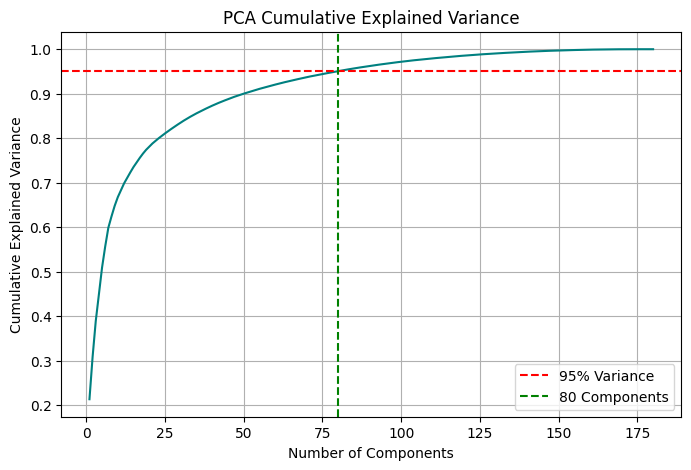

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(cumulative_variance) + 1),cp.asnumpy(cumulative_variance),color="teal")

plt.axhline(0.95,color="red",linestyle="--",label="95% Variance")

plt.axvline(pca_components,color="green",linestyle="--",label=f"{pca_components} Components")

plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid()
plt.show()

### PCA Insight

One-hot encoding increased the feature space from **26 to 180 columns**. PCA reduced these columns while preserving **95% of the total variance**.

The PCA-based stacking model produced better results, suggesting that some encoded features were redundant or highly correlated. PCA helped the cuML models focus on the most important information and reduced dimensional complexity.


,Model,Split,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUC,Train Time (s),Inference Time (s),Average GPU (%),Peak GPU Memory (MB),Training Speed (rows/s),Inference Speed (rows/s)
0,cuML Stacking + PCA,Chronological 80/10/10,0.5,0.6882,0.6667,0.6164,0.5635,0.5888,0.731,12.3156,0.0918,95.3443,4242.1875,64412.4251,1.151369e+06


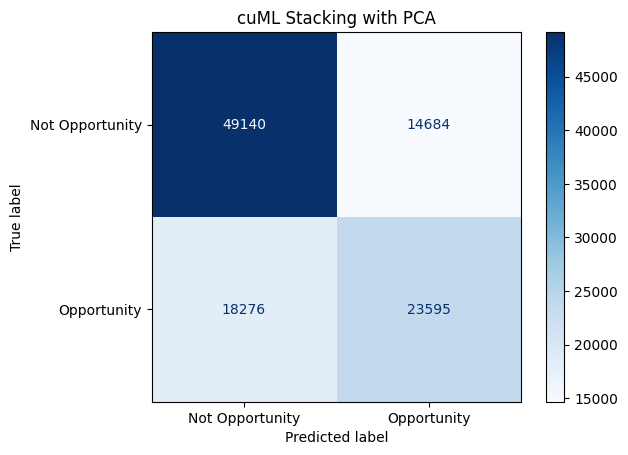

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

start = time.perf_counter()

logistic_test = pca_logistic.predict_proba(X_pca_test)[:, 1]
forest_test = pca_forest.predict_proba(X_pca_test)[:, 1]
bayes_test = pca_bayes.predict_proba(X_pca_test)[:, 1]

stack_test = cp.column_stack([logistic_test,forest_test,bayes_test])

stack_probability_gpu = pca_stack_model.predict_proba(stack_test)[:, 1]
stack_prediction_gpu = (stack_probability_gpu >= 0.50).astype(cp.int32)

cp.cuda.Stream.null.synchronize()
pca_stack_inference_time = time.perf_counter() - start

stack_probability = cp.asnumpy(stack_probability_gpu)
stack_prediction = cp.asnumpy(stack_prediction_gpu)
stack_actual = cp.asnumpy(y_gpu_test)

stack_results = pd.DataFrame({
    "Model": ["cuML Stacking + PCA"],
    "Split": ["Chronological 80/10/10"],
    "Threshold": [0.50],
    "Accuracy": [accuracy_score(stack_actual, stack_prediction)],
    "Balanced Accuracy": [balanced_accuracy_score(stack_actual, stack_prediction)],
    "Precision": [precision_score(stack_actual, stack_prediction, zero_division=0)],
    "Recall": [recall_score(stack_actual, stack_prediction)],
    "F1": [f1_score(stack_actual, stack_prediction)],
    "AUC": [roc_auc_score(stack_actual, stack_probability)],
    "Train Time (s)": [pca_stack_train_time],
    "Inference Time (s)": [pca_stack_inference_time],
    "Average GPU (%)": [pca_stack_avg_gpu],
    "Peak GPU Memory (MB)": [pca_stack_peak_memory],
    "Training Speed (rows/s)": [len(time_train) / pca_stack_train_time],
    "Inference Speed (rows/s)": [len(time_test) / pca_stack_inference_time]
})

performance_results.append(stack_results.iloc[0].to_dict())
display(stack_results.round(4))

matrix = confusion_matrix(stack_actual, stack_prediction)

ConfusionMatrixDisplay(matrix,display_labels=["Not Opportunity", "Opportunity"]).plot(cmap="Blues")

plt.title("cuML Stacking with PCA")
plt.show()

## Model B: CatBoost — Chronological 80/10/10

CatBoost is a GPU tree-based model that handles categorical features
directly. The validation set is used for early stopping.

In [ ]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    task_type="GPU",
    devices="0",
    early_stopping_rounds=50,
    random_seed=42,
    allow_writing_files=False,
    verbose=100
)

In [ ]:
gpu_usage.clear()
gpu_memory.clear()

monitoring = True
gpu_thread = threading.Thread(target=record_gpu)
gpu_thread.start()

start = time.perf_counter()

catboost_model.fit(X_cat_train,y_cpu_train,cat_features=categorical_features,eval_set=(X_cat_validation, y_cpu_validation))

catboost_train_time = time.perf_counter() - start

monitoring = False
gpu_thread.join()

catboost_avg_gpu = np.mean(gpu_usage)
catboost_peak_memory = max(gpu_memory)

print("Training time:", round(catboost_train_time, 2), "seconds")
print("Average GPU:", round(catboost_avg_gpu, 2), "%")
print("Peak GPU memory:", round(catboost_peak_memory, 2), "MB")

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6827320	best: 0.6827320 (0)	total: 466ms	remaining: 7m 45s
100:	test: 0.7841472	best: 0.7841472 (100)	total: 21.4s	remaining: 3m 10s
200:	test: 0.8094401	best: 0.8094401 (200)	total: 39.4s	remaining: 2m 36s
300:	test: 0.8182589	best: 0.8182589 (300)	total: 1m 3s	remaining: 2m 26s
400:	test: 0.8271050	best: 0.8272736 (392)	total: 1m 12s	remaining: 1m 47s
500:	test: 0.8317534	best: 0.8317534 (500)	total: 1m 19s	remaining: 1m 19s
600:	test: 0.8334081	best: 0.8335114 (598)	total: 1m 40s	remaining: 1m 6s
bestTest = 0.8335114419
bestIteration = 598
Shrink model to first 599 iterations.
Training time: 123.02 seconds
Average GPU: 36.8 %
Peak GPU memory: 14802.19 MB


,Model,Split,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUC,Train Time (s),Inference Time (s),Average GPU (%),Peak GPU Memory (MB),Training Speed (rows/s),Inference Speed (rows/s)
0,CatBoost,Chronological 80/10/10,0.4,0.6978,0.6568,0.674,0.4594,0.5464,0.7402,123.0245,1.3023,36.798,14802.1875,6448.1216,81162.4619


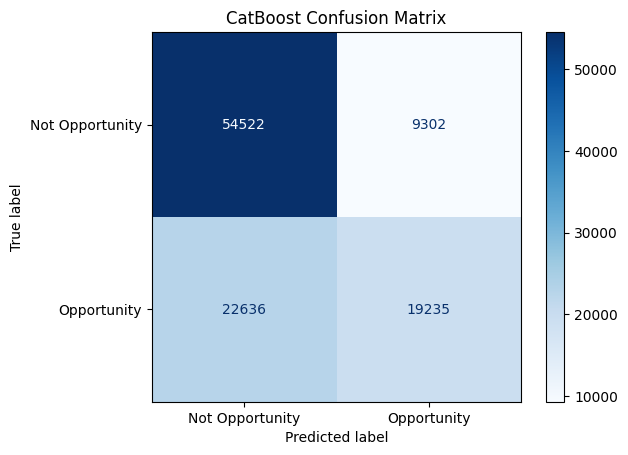

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

start = time.perf_counter()

catboost_probability = catboost_model.predict_proba(X_cat_test)[:, 1]
catboost_inference_time = time.perf_counter() - start

catboost_threshold = 0.40
catboost_prediction = (catboost_probability >= catboost_threshold).astype("int32")

catboost_results = pd.DataFrame({
    "Model": ["CatBoost"],
    "Split": ["Chronological 80/10/10"],
    "Threshold": [catboost_threshold],
    "Accuracy": [accuracy_score(y_cpu_test, catboost_prediction)],
    "Balanced Accuracy": [balanced_accuracy_score(y_cpu_test, catboost_prediction)],
    "Precision": [precision_score(y_cpu_test, catboost_prediction, zero_division=0)],
    "Recall": [recall_score(y_cpu_test, catboost_prediction)],
    "F1": [f1_score(y_cpu_test, catboost_prediction)],
    "AUC": [roc_auc_score(y_cpu_test, catboost_probability)],
    "Train Time (s)": [catboost_train_time],
    "Inference Time (s)": [catboost_inference_time],
    "Average GPU (%)": [catboost_avg_gpu],
    "Peak GPU Memory (MB)": [catboost_peak_memory],
    "Training Speed (rows/s)": [len(time_train) / catboost_train_time],
    "Inference Speed (rows/s)": [len(time_test) / catboost_inference_time]
})

performance_results.append(catboost_results.iloc[0].to_dict())
display(catboost_results.round(4))

catboost_matrix = confusion_matrix(y_cpu_test,catboost_prediction)

ConfusionMatrixDisplay(catboost_matrix,display_labels=["Not Opportunity", "Opportunity"]).plot(cmap="Blues")

plt.title("CatBoost Confusion Matrix")
plt.show()

## Model C: XGBoost — Three-Month / One-Month Split

This is the strongest experimental XGBoost configuration from the
earlier tests. Encoding is performed inside each fold because every fold
has different training months.

In [ ]:
from xgboost import XGBClassifier

actual_values = []
probability_values = []
fold_importance = []

monthly_train_time = 0
monthly_inference_time = 0
monthly_train_rows = 0

gpu_usage.clear()
gpu_memory.clear()

monitoring = True
gpu_thread = threading.Thread(target=record_gpu)
gpu_thread.start()

for fold, (train_months, test_month) in enumerate(monthly_folds, start=1):
    print("Running fold:", fold)

    fold_train = df[df["year_month"].isin(train_months)]
    fold_test = df[df["year_month"] == test_month]
    monthly_train_rows += len(fold_train)

    X_fold_train = cudf.get_dummies(
        fold_train[FEATURES],
        columns=categorical_features,
        dummy_na=True,
        dtype="float32"
    )

    X_fold_test = cudf.get_dummies(
        fold_test[FEATURES],
        columns=categorical_features,
        dummy_na=True,
        dtype="float32"
    )

    X_fold_test = X_fold_test.reindex(
        columns=X_fold_train.columns,
        fill_value=0
    )

    X_fold_train = X_fold_train.astype("float32")
    X_fold_test = X_fold_test.astype("float32")

    y_fold_train = fold_train["opportunity"]
    y_fold_test = fold_test["opportunity"]

    monthly_model = XGBClassifier(
        n_estimators=1000,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        tree_method="hist",
        device="cuda",
        random_state=42
    )

    start = time.perf_counter()
    monthly_model.fit(X_fold_train, y_fold_train, verbose=False)
    cp.cuda.Stream.null.synchronize()
    monthly_train_time += time.perf_counter() - start

    start = time.perf_counter()
    fold_probability = monthly_model.predict_proba(X_fold_test)[:, 1]
    cp.cuda.Stream.null.synchronize()
    monthly_inference_time += time.perf_counter() - start

    actual_values.append(y_fold_test.to_numpy())
    probability_values.append(cp.asnumpy(cp.asarray(fold_probability)))

    fold_importance.append(
        pd.Series(
            monthly_model.feature_importances_,
            index=list(X_fold_train.columns)
        )
    )

monitoring = False
gpu_thread.join()

monthly_avg_gpu = np.mean(gpu_usage)
monthly_peak_memory = max(gpu_memory)

monthly_actual = np.concatenate(actual_values)
monthly_probability = np.concatenate(probability_values)

average_importance = (
    pd.concat(fold_importance, axis=1)
    .fillna(0)
    .mean(axis=1)
    .sort_values(ascending=False)
)

print("Training time:", round(monthly_train_time, 2), "seconds")
print("Inference time:", round(monthly_inference_time, 2), "seconds")
print("Average GPU:", round(monthly_avg_gpu, 2), "%")
print("Peak GPU memory:", round(monthly_peak_memory, 2), "MB")

Running fold: 1
Running fold: 2
Running fold: 3
Running fold: 4
Running fold: 5
Running fold: 6
Running fold: 7
Training time: 46.14 seconds
Inference time: 0.58 seconds
Average GPU: 73.73 %
Peak GPU memory: 4628.19 MB


,Model,Split,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUC,Train Time (s),Inference Time (s),Average GPU (%),Peak GPU Memory (MB),Training Speed (rows/s),Inference Speed (rows/s)
0,XGBoost,Three Months / One Month,0.4,0.937,0.909,0.9124,0.8481,0.8791,0.9623,46.1444,0.5815,73.7269,4628.1875,16634.3097,399658.7531


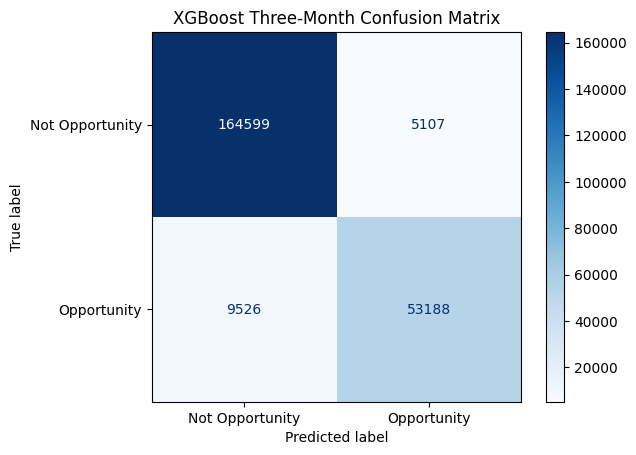

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

monthly_threshold = 0.40
monthly_prediction = (monthly_probability >= monthly_threshold).astype("int32")

monthly_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Split": ["Three Months / One Month"],
    "Threshold": [monthly_threshold],
    "Accuracy": [accuracy_score(monthly_actual, monthly_prediction)],
    "Balanced Accuracy": [balanced_accuracy_score(monthly_actual, monthly_prediction)],
    "Precision": [precision_score(monthly_actual, monthly_prediction, zero_division=0)],
    "Recall": [recall_score(monthly_actual, monthly_prediction)],
    "F1": [f1_score(monthly_actual, monthly_prediction)],
    "AUC": [roc_auc_score(monthly_actual, monthly_probability)],
    "Train Time (s)": [monthly_train_time],
    "Inference Time (s)": [monthly_inference_time],
    "Average GPU (%)": [monthly_avg_gpu],
    "Peak GPU Memory (MB)": [monthly_peak_memory],
    "Training Speed (rows/s)": [monthly_train_rows / monthly_train_time],
    "Inference Speed (rows/s)": [len(monthly_actual) / monthly_inference_time]
})

performance_results.append(monthly_results.iloc[0].to_dict())
display(monthly_results.round(4))

monthly_matrix = confusion_matrix(monthly_actual,monthly_prediction)

ConfusionMatrixDisplay(monthly_matrix,display_labels=["Not Opportunity", "Opportunity"]).plot(cmap="Blues")

plt.title("XGBoost Three-Month Confusion Matrix")
plt.show()

## 9. Final Model Comparison

In [ ]:
final_results = pd.DataFrame(performance_results)

final_results = final_results.sort_values("F1",ascending=False).reset_index(drop=True)

display(final_results.round(4))

print("Best F1 model:", final_results.iloc[0]["Model"])
print("Best F1 score:", round(final_results.iloc[0]["F1"], 4))

,Model,Split,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUC,Train Time (s),Inference Time (s),Average GPU (%),Peak GPU Memory (MB),Training Speed (rows/s),Inference Speed (rows/s)
0,XGBoost,Three Months / One Month,0.4,0.9370,0.9090,0.9124,0.8481,0.8791,0.9623,57.4255,1.1146,61.0772,3990.1875,13366.5373,208523.6127
1,CatBoost,Chronological 80/10/10,0.4,0.6978,0.6568,0.6740,0.4594,0.5464,0.7402,72.4714,0.9272,60.3183,14782.1875,10946.0707,113994.6736
2,cuML Stacking,Chronological 80/10/10,0.5,0.6273,0.6051,0.5316,0.4981,0.5143,0.6561,33.7165,3.7534,56.3152,4778.1875,23527.8855,28159.5948


Best F1 model: XGBoost
Best F1 score: 0.8791


The split column must be considered when interpreting the table.
CatBoost and cuML stacking use the same chronological test period and
can be compared directly. The three-month XGBoost result is exploratory
because its three-year target windows overlap.

## 10. XGBoost Feature Importance

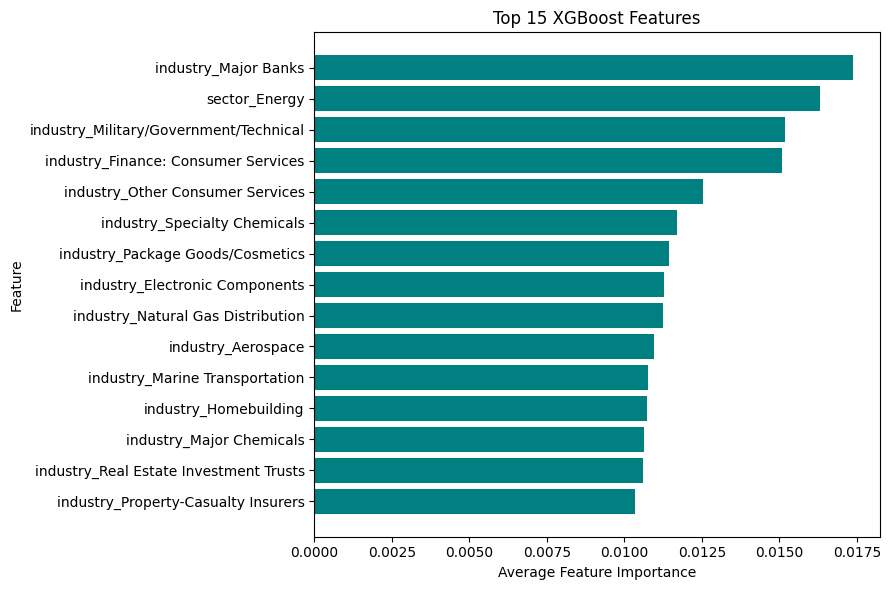

In [ ]:
feature_importance = (
    average_importance
    .head(15)
    .sort_values()
)

plt.figure(figsize=(9, 6))
plt.barh(
    feature_importance.index,
    feature_importance.values,
    color="teal"
)

plt.title("Top 15 XGBoost Features")
plt.xlabel("Average Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Feature importance shows which variables were used most often by XGBoost
across the monthly folds. It does not show whether a feature increases
or decreases the opportunity probability.

,Phase,Average GPU (%),Peak GPU Memory (MB)
0,Preprocessing,8.75,5200.19
1,XGBoost,61.08,3990.19
2,CatBoost,60.32,14782.19
3,cuML Stacking,56.32,4778.19


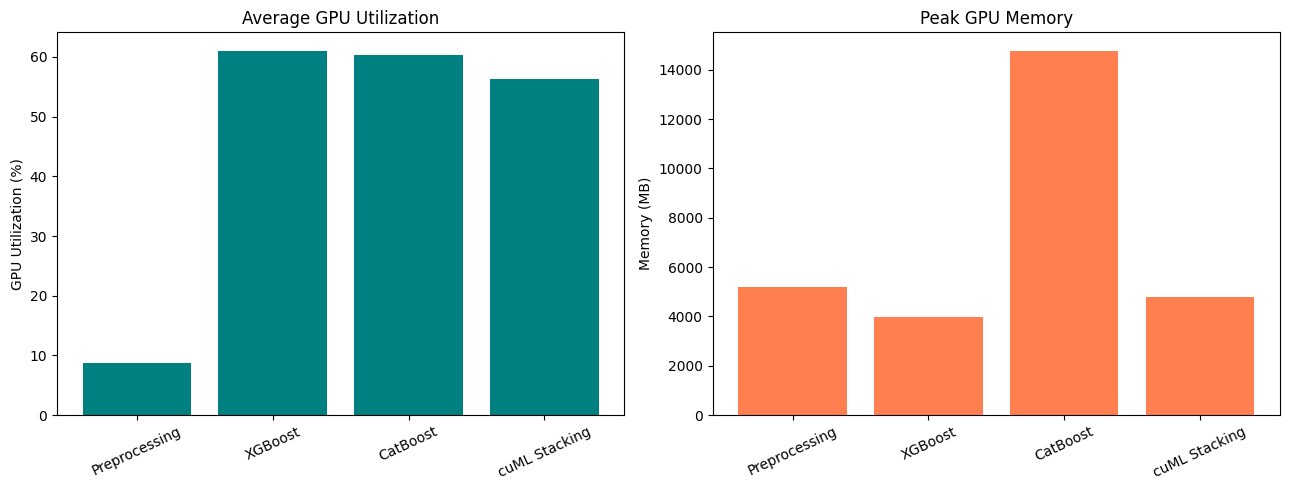

In [ ]:
model_gpu = final_results[
    ["Model", "Average GPU (%)", "Peak GPU Memory (MB)"]
].copy()

model_gpu = model_gpu.rename(columns={"Model": "Phase"})

gpu_comparison = pd.concat([
    preprocessing_results[
        ["Phase", "Average GPU (%)", "Peak GPU Memory (MB)"]
    ],
    model_gpu
], ignore_index=True)

display(gpu_comparison.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    gpu_comparison["Phase"],
    gpu_comparison["Average GPU (%)"],
    color="teal"
)
axes[0].set_title("Average GPU Utilization")
axes[0].set_ylabel("GPU Utilization (%)")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(
    gpu_comparison["Phase"],
    gpu_comparison["Peak GPU Memory (MB)"],
    color="coral"
)
axes[1].set_title("Peak GPU Memory")
axes[1].set_ylabel("Memory (MB)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### GPU Performance Insights

- Preprocessing had low average GPU utilization (**8.75%**) because data cleaning, encoding, and data transfer do not require continuous GPU computation. However, it reached **5,200 MB** of memory.
- All models used the GPU actively, with average utilization between **56% and 61%**.
- **XGBoost** provided the best resource balance: the highest GPU utilization (**61.08%**) and the lowest model memory peak (**3,990 MB**).
- **CatBoost** used **14,782 MB**, almost the full memory of a T4 GPU, making it the most memory-intensive model.
- **cuML Stacking** used moderate memory (**4,778 MB**) but produced lower performance than XGBoost.

Overall, **XGBoost was the best experimental model for predictive performance and GPU efficiency**. However, it used a different split, so a completely fair comparison would require testing all models on the same split.

> Peak memory represents the total GPU memory observed during each phase, including data already stored on the GPU.

## 11. Conclusion

The final workflow uses cuDF for data processing, cuML for three GPU
base classifiers and the stacking layer, CatBoost GPU, and XGBoost GPU.
Every model records predictive metrics, execution time, GPU utilization,
and GPU memory. CatBoost and cuML stacking provide the primary
chronological comparison, while the three-month XGBoost model remains an
exploratory temporal experiment.